# HDB Resale Price — PCA Analysis

This notebook applies **Principal Component Analysis (PCA)** to identify which features matter most for predicting HDB resale prices. We analyse three natural feature groups:

1. **Amenity Accessibility** — distances and counts for malls, hawkers, MRT, bus stops, schools  
2. **Unit Mix** — room type sold/rental composition of the building  
3. **Building Characteristics** — size, age, floor levels  

**Goal:** Reduce dimensionality while retaining 95% variance, and interpret what each principal component represents.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/train.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (150634, 77)


/var/folders/mx/_44pwh5j0y1dn2nxq888m1hm0000gn/T/ipykernel_59046/2018187310.py:14: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/train.csv')


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,...,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,...,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,...,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013


## 1. Feature Groups

We split numeric features into three semantically coherent groups for PCA. Categorical, temporal, and target columns are excluded.

In [2]:
AMENITY_COLS = [
    'Mall_Nearest_Distance', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km',
    'Hawker_Nearest_Distance', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km',
    'hawker_food_stalls', 'hawker_market_stalls',
    'mrt_nearest_distance', 'bus_stop_nearest_distance',
    'pri_sch_nearest_distance', 'sec_sch_nearest_dist',
]

UNIT_MIX_COLS = [
    '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold',
    'exec_sold', 'multigen_sold', 'studio_apartment_sold',
    '1room_rental', '2room_rental', '3room_rental', 'other_room_rental',
]

BUILDING_COLS = [
    'floor_area_sqm', 'floor_area_sqft', 'hdb_age', 'max_floor_lvl',
    'year_completed', 'total_dwelling_units', 'mid_storey', 'mid',
]

ALL_GROUPS = {
    'Amenity Accessibility': AMENITY_COLS,
    'Unit Mix': UNIT_MIX_COLS,
    'Building Characteristics': BUILDING_COLS,
}

for name, cols in ALL_GROUPS.items():
    missing = [c for c in cols if c not in df.columns]
    print(f"{name}: {len(cols)} features | missing from data: {missing}")

Amenity Accessibility: 14 features | missing from data: []
Unit Mix: 12 features | missing from data: []
Building Characteristics: 8 features | missing from data: []


## 2. Correlation Heatmaps (Before PCA)

High intra-group correlation confirms PCA is appropriate — correlated features carry redundant information.

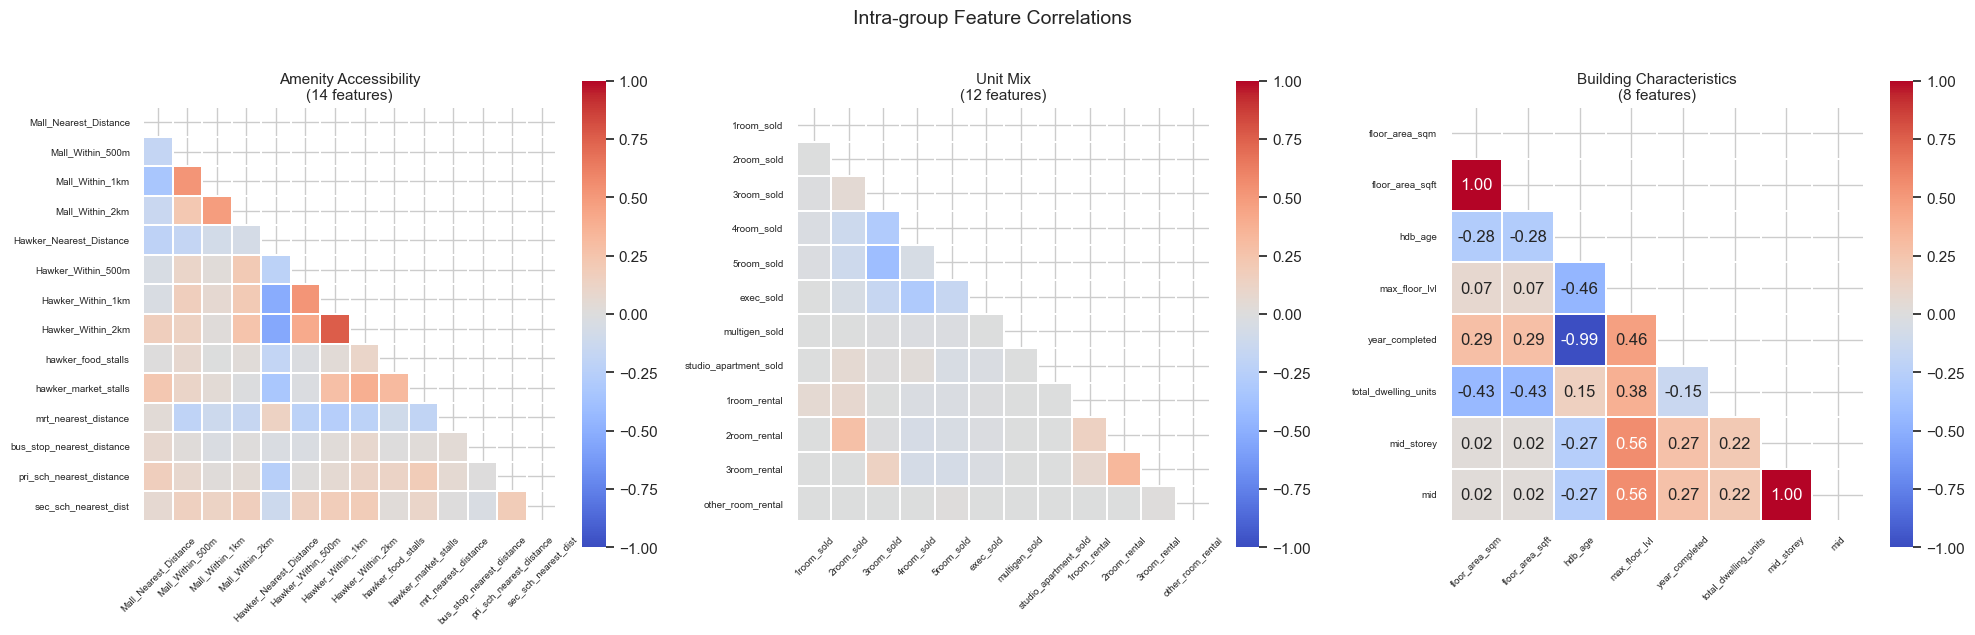

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, cols) in zip(axes, ALL_GROUPS.items()):
    valid_cols = [c for c in cols if c in df.columns]
    corr = df[valid_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, annot=len(valid_cols) <= 10,
                fmt='.2f', linewidths=0.3, square=True,
                xticklabels=True, yticklabels=True)
    ax.set_title(f'{name}\n({len(valid_cols)} features)', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Intra-group Feature Correlations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. PCA per Feature Group

For each group we:
1. Impute missing values (median)
2. Standardise (zero mean, unit variance) — **required** before PCA
3. Fit PCA and plot the **scree / cumulative explained variance** curve
4. Inspect **loadings** to name the components

In [4]:
def run_pca(df, cols, group_name, n_components=None, variance_threshold=0.95):
    valid_cols = [c for c in cols if c in df.columns]
    X = df[valid_cols].copy()

    imputer = SimpleImputer(strategy='median')
    X_imp = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    pca_full = PCA().fit(X_scaled)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_95 = int(np.searchsorted(cumvar, variance_threshold)) + 1

    pca = PCA(n_components=n_95)
    components = pca.fit_transform(X_scaled)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=valid_cols,
        columns=[f'PC{i+1}' for i in range(n_95)]
    )

    return {
        'name': group_name,
        'cols': valid_cols,
        'pca': pca,
        'pca_full': pca_full,
        'components': components,
        'loadings': loadings,
        'cumvar': cumvar,
        'n_95': n_95,
    }

results = {name: run_pca(df, cols, name) for name, cols in ALL_GROUPS.items()}

for name, r in results.items():
    ev = r['pca'].explained_variance_ratio_
    print(f"\n{'='*55}")
    print(f"{name}")
    print(f"  Original features : {len(r['cols'])}")
    print(f"  PCs for 95% var   : {r['n_95']}")
    for i, v in enumerate(ev):
        cum = np.cumsum(ev)[i]
        print(f"  PC{i+1}: {v*100:.1f}%  (cumulative {cum*100:.1f}%)")


Amenity Accessibility
  Original features : 14
  PCs for 95% var   : 12
  PC1: 21.5%  (cumulative 21.5%)
  PC2: 14.0%  (cumulative 35.5%)
  PC3: 9.5%  (cumulative 44.9%)
  PC4: 8.4%  (cumulative 53.3%)
  PC5: 7.3%  (cumulative 60.6%)
  PC6: 6.3%  (cumulative 66.9%)
  PC7: 5.8%  (cumulative 72.8%)
  PC8: 5.5%  (cumulative 78.3%)
  PC9: 5.1%  (cumulative 83.3%)
  PC10: 4.8%  (cumulative 88.1%)
  PC11: 4.1%  (cumulative 92.2%)
  PC12: 3.4%  (cumulative 95.6%)

Unit Mix
  Original features : 12
  PCs for 95% var   : 11
  PC1: 14.0%  (cumulative 14.0%)
  PC2: 11.2%  (cumulative 25.2%)
  PC3: 10.3%  (cumulative 35.6%)
  PC4: 8.9%  (cumulative 44.4%)
  PC5: 8.6%  (cumulative 53.0%)
  PC6: 8.3%  (cumulative 61.4%)
  PC7: 8.3%  (cumulative 69.7%)
  PC8: 8.1%  (cumulative 77.8%)
  PC9: 7.9%  (cumulative 85.7%)
  PC10: 7.5%  (cumulative 93.1%)
  PC11: 4.5%  (cumulative 97.6%)

Building Characteristics
  Original features : 8
  PCs for 95% var   : 4
  PC1: 40.0%  (cumulative 40.0%)
  PC2: 31.0%  

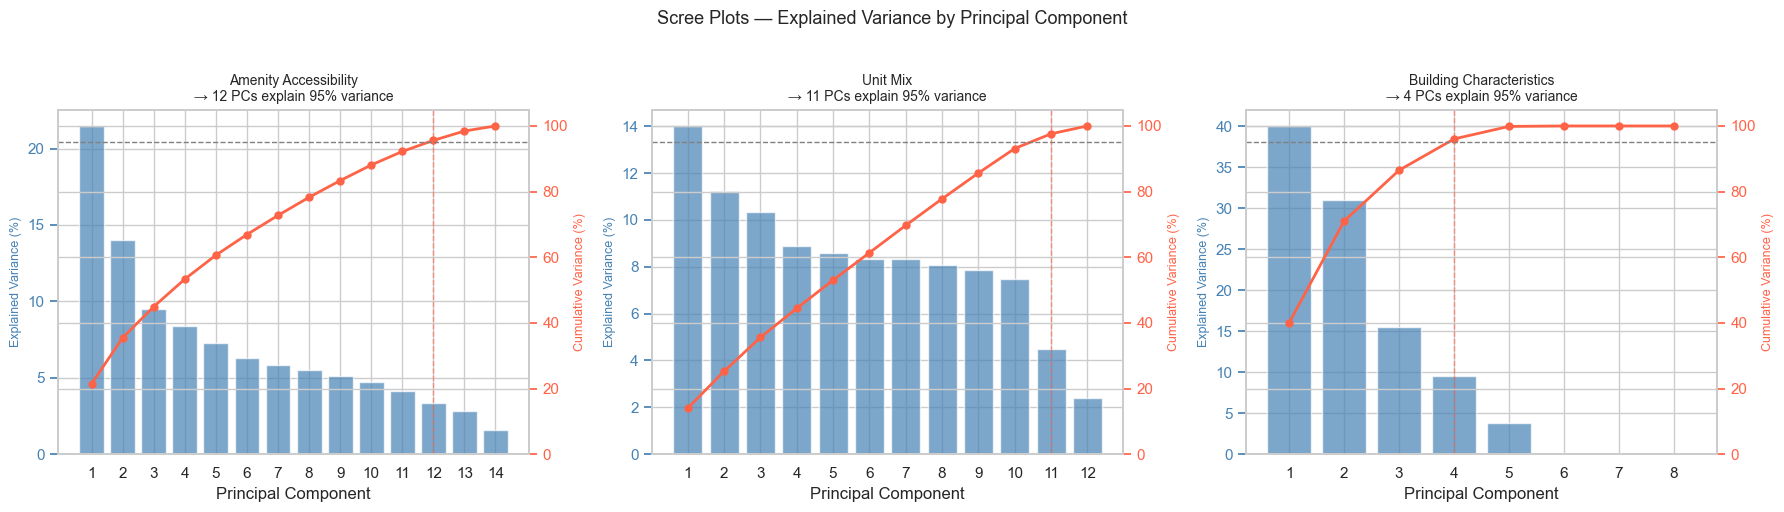

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    ev_ratio = r['pca_full'].explained_variance_ratio_
    cumvar = r['cumvar']
    x = np.arange(1, len(ev_ratio) + 1)

    ax.bar(x, ev_ratio * 100, color='steelblue', alpha=0.7, label='Individual')
    ax2 = ax.twinx()
    ax2.plot(x, cumvar * 100, 'o-', color='tomato', linewidth=2, markersize=5, label='Cumulative')
    ax2.axhline(95, linestyle='--', color='grey', linewidth=1)
    ax2.axvline(r['n_95'], linestyle='--', color='tomato', linewidth=1, alpha=0.6)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel('Cumulative Variance (%)', color='tomato', fontsize=9)
    ax2.tick_params(axis='y', colors='tomato')

    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance (%)', color='steelblue', fontsize=9)
    ax.tick_params(axis='y', colors='steelblue')
    ax.set_title(f'{name}\n→ {r["n_95"]} PCs explain 95% variance', fontsize=10)
    ax.set_xticks(x)

plt.suptitle('Scree Plots — Explained Variance by Principal Component', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. PCA Loadings — What Does Each Component Represent?

Loadings show how much each original feature contributes to a PC. Large absolute values (positive or negative) = dominant drivers.

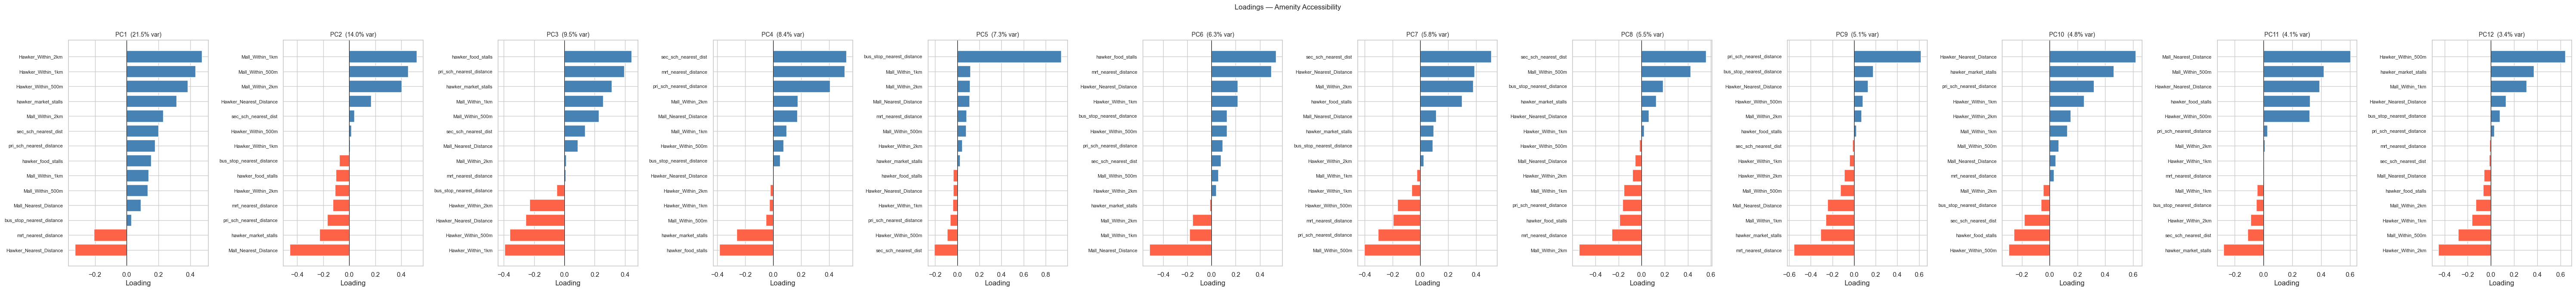

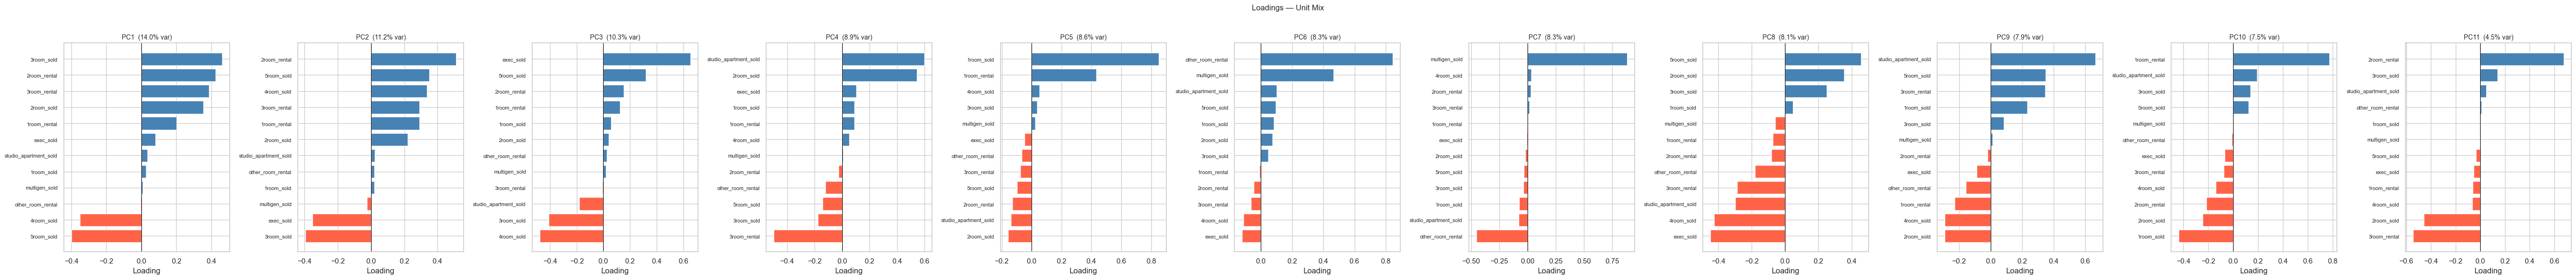

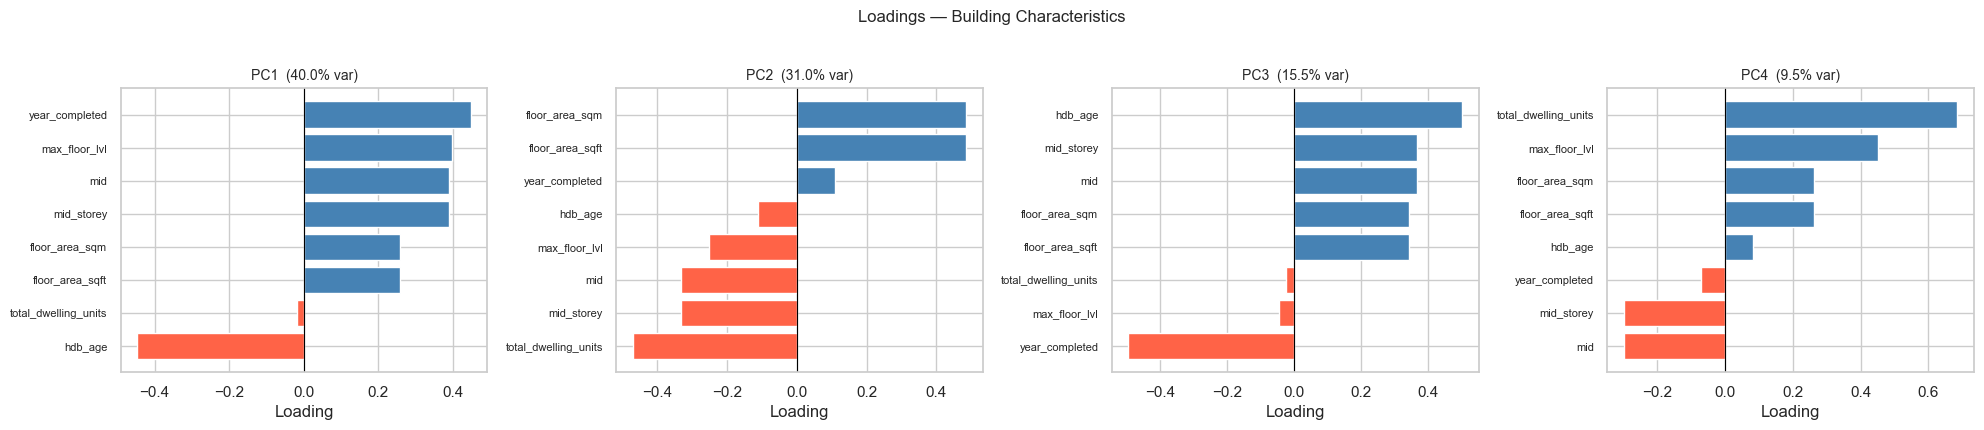

In [6]:
for name, r in results.items():
    loadings = r['loadings']
    n_pcs = loadings.shape[1]
    fig, axes = plt.subplots(1, n_pcs, figsize=(5 * n_pcs, max(4, len(r['cols']) * 0.4 + 1)))
    if n_pcs == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        pc = f'PC{i+1}'
        vals = loadings[pc].sort_values()
        colors = ['tomato' if v < 0 else 'steelblue' for v in vals]
        ax.barh(vals.index, vals.values, color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{pc}  ({r["pca"].explained_variance_ratio_[i]*100:.1f}% var)', fontsize=10)
        ax.set_xlabel('Loading')
        ax.tick_params(axis='y', labelsize=8)

    fig.suptitle(f'Loadings — {name}', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Feature Importance via Correlation with Resale Price

Beyond PCA, we check which **individual features correlate most strongly** with `resale_price` — this tells us which dimensions matter most for the prediction task.

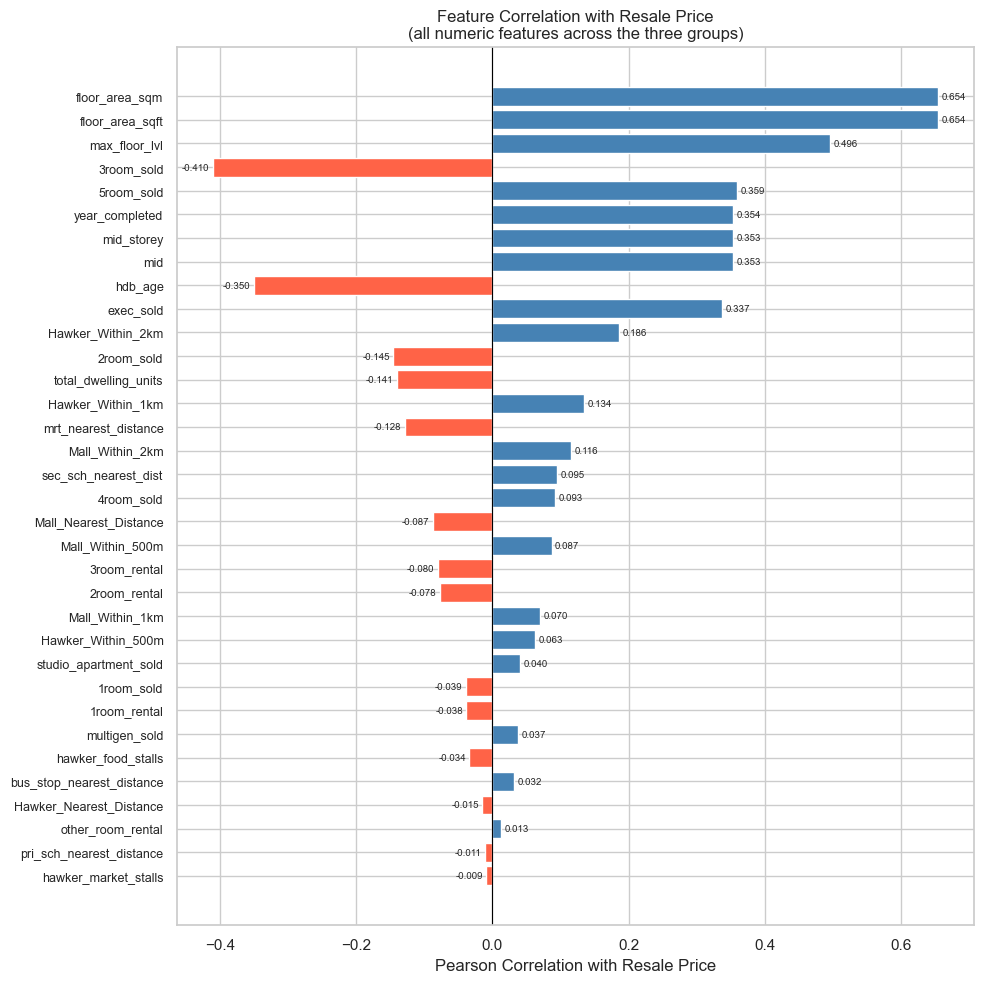

In [7]:
all_feature_cols = AMENITY_COLS + UNIT_MIX_COLS + BUILDING_COLS
valid_feature_cols = [c for c in all_feature_cols if c in df.columns]

corr_with_price = (
    df[valid_feature_cols + ['resale_price']]
    .corr()['resale_price']
    .drop('resale_price')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_price]
ax.barh(corr_with_price.index[::-1], corr_with_price.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Resale Price')
ax.set_title('Feature Correlation with Resale Price\n(all numeric features across the three groups)', fontsize=12)
ax.tick_params(axis='y', labelsize=9)

for i, (val, feat) in enumerate(zip(corr_with_price.values[::-1], corr_with_price.index[::-1])):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7)

plt.tight_layout()
plt.show()

## 6. PC Scores vs Resale Price

We scatter PC1 (the dominant component in each group) against `resale_price` to visually confirm whether the compressed representation retains predictive signal.

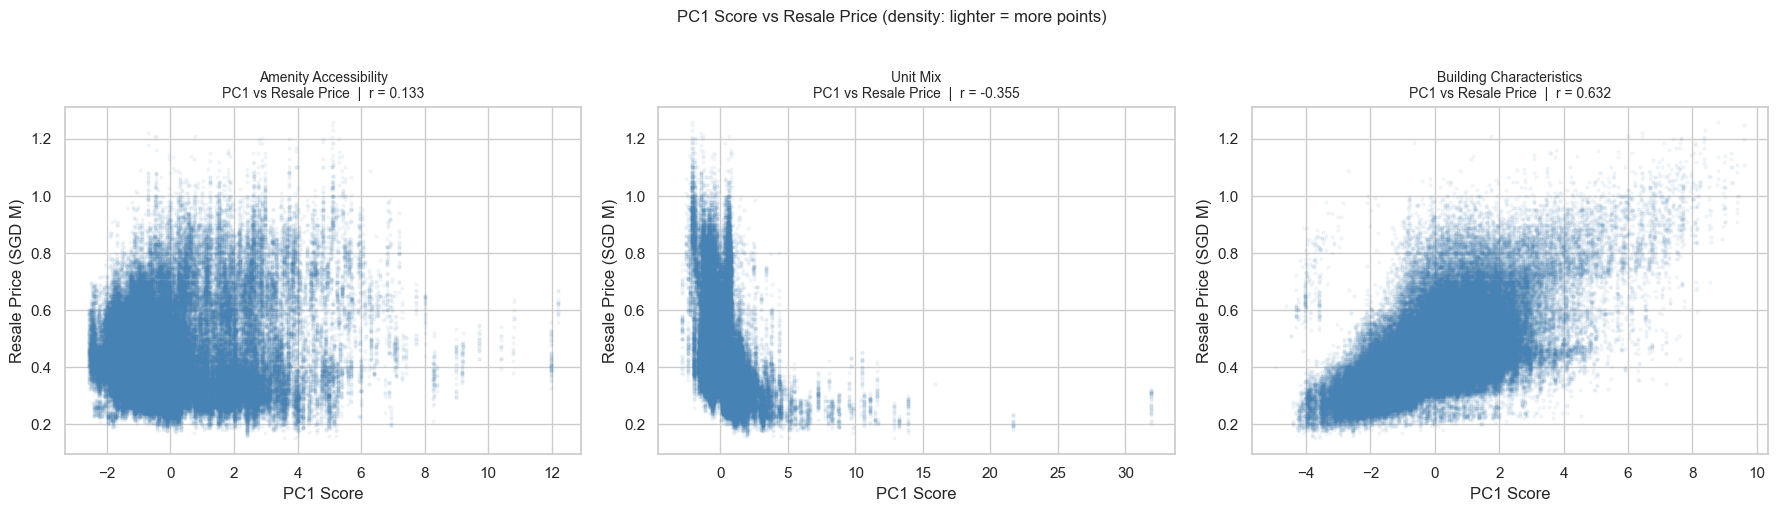

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
price = df['resale_price'].values

for ax, (name, r) in zip(axes, results.items()):
    pc1 = r['components'][:, 0]
    corr_val = np.corrcoef(pc1, price)[0, 1]

    ax.scatter(pc1, price / 1e6, alpha=0.05, s=5, color='steelblue')
    ax.set_xlabel('PC1 Score')
    ax.set_ylabel('Resale Price (SGD M)')
    ax.set_title(f'{name}\nPC1 vs Resale Price  |  r = {corr_val:.3f}', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.suptitle('PC1 Score vs Resale Price (density: lighter = more points)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary Table — Dimensionality Reduction Results

In [9]:
rows = []
for name, r in results.items():
    ev = r['pca'].explained_variance_ratio_
    pc1_corr = abs(np.corrcoef(r['components'][:, 0], df['resale_price'].values)[0, 1])
    top_loading = r['loadings']['PC1'].abs().idxmax()
    rows.append({
        'Group': name,
        'Original Features': len(r['cols']),
        'PCs (95% var)': r['n_95'],
        'PC1 Variance': f"{ev[0]*100:.1f}%",
        'PC2 Variance': f"{ev[1]*100:.1f}%" if len(ev) > 1 else '—',
        'PC1 |corr| w/ Price': f"{pc1_corr:.3f}",
        'PC1 Top Driver': top_loading,
    })

summary = pd.DataFrame(rows).set_index('Group')
summary

,Original Features,PCs (95% var),PC1 Variance,PC2 Variance,PC1 |corr| w/ Price,PC1 Top Driver
Group,,,,,,
Amenity Accessibility,14,12,21.5%,14.0%,0.133,Hawker_Within_2km
Unit Mix,12,11,14.0%,11.2%,0.355,3room_sold
Building Characteristics,8,4,40.0%,31.0%,0.632,year_completed


## 8. Key Insights

### Amenity Accessibility
- `Mall_Within_*` and `Hawker_Within_*` columns are **nearly redundant** — they are monotonically derived from the nearest distance. PC1 likely captures an overall **"urban density / convenience"** axis.  
- `mrt_nearest_distance` tends to be the most price-sensitive single amenity: proximity to MRT is a well-known premium driver in Singapore.

### Unit Mix
- Buildings skewed toward **larger flat types** (4-room, 5-room, exec) naturally command higher prices — PC1 here is essentially a **"flat size popularity"** axis.  
- Studio / 1-room sold counts load negatively (older, smaller estates with lower prices).

### Building Characteristics
- `floor_area_sqm` / `floor_area_sqft` are perfectly correlated (unit conversion) — **drop one** before modelling.  
- `hdb_age` and `year_completed` are also nearly perfect negatives of each other — **drop one**.  
- `mid_storey` is a strong positive driver: higher floors → better views → premium price.

### What to Drop / Combine for Modelling
| Action | Columns |
|---|---|
| Drop (duplicates) | `floor_area_sqft`, `hdb_age` (keep `year_completed`), `lower`, `upper`, `mid` (keep `mid_storey`) |
| PCA-compress | Amenity cluster (14 → ~3 PCs), Unit mix (12 → ~4 PCs) |
| Keep raw | `floor_area_sqm`, `mid_storey`, `max_floor_lvl`, `mrt_nearest_distance`, `Tranc_Year`, `Tranc_Month` |
| Encode categorically | `town`, `flat_type`, `flat_model`, `planning_area` |